# EDA Final: Diagnóstico de Errores de Pronóstico Climático

Este notebook consolida el análisis estadístico de los errores de pronóstico frente a observaciones reales, con el fin de fundamentar la estrategia de Machine Learning.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid")
df = pd.read_parquet("local_cleanup/clima_unificado.parquet")

df["hour"] = df["obs_timestamp"].dt.hour

# 2. Cálculo de errores (Residuos)
df["err_temp"] = df["temp_fcst"] - df["temp_real"]
df["err_hum"] = df["hum_fcst"] - df["hum_real"]
df["err_wind"] = df["wind_speed_fcst"] - df["wind_speed_real"]
df["err_dew"] = df["dew_fcst"] - df["dew_real"]


print(f"Dataset cargado y limpio: {len(df)} registros.")

Dataset cargado y limpio: 116854 registros.


## 1. Correlacion entre variables

**Observaciónes:**

- Correlacion fuerte entre `temp_real`, `dew_real` y `hum_real`, esperable por la relacion fisica entre las variables.


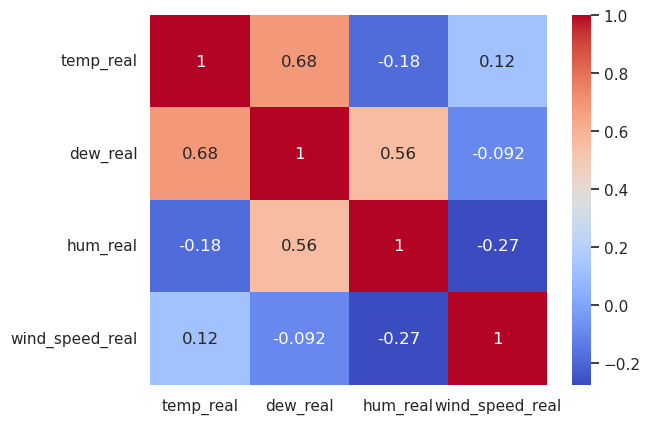

In [13]:
vars = ["temp_real", "dew_real", "hum_real", "wind_speed_real"]
sns.heatmap(df[vars].corr(), annot=True, cmap="coolwarm")
plt.show()

## 3. Análisis de Sesgo Diurno

**Observaciones:**

- Se detecta una **sobreestimación nocturna** constante y una **subestimación diurna**.
- Esto sugiere que el modelo de ML necesita la hora como variable predictora, preferiblemente transformada en componentes sinusoidales.


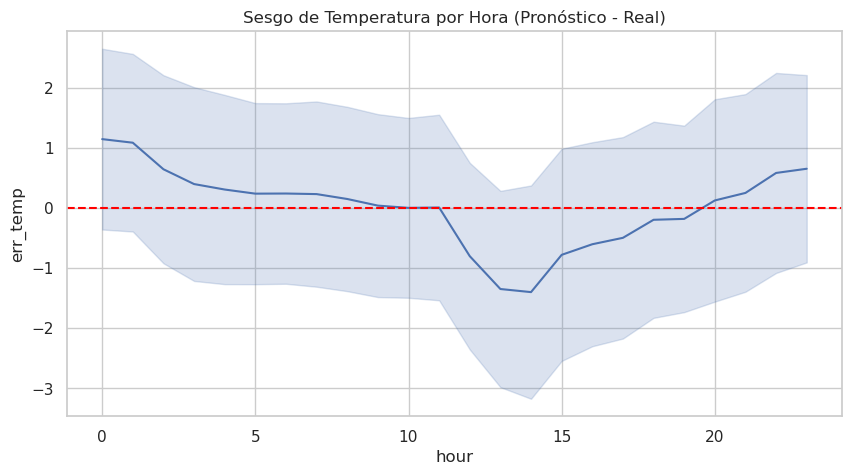

In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="hour", y="err_temp", errorbar="sd")
plt.axhline(0, color="red", linestyle="--")
plt.title("Sesgo de Temperatura por Hora (Pronóstico - Real)")
plt.show()

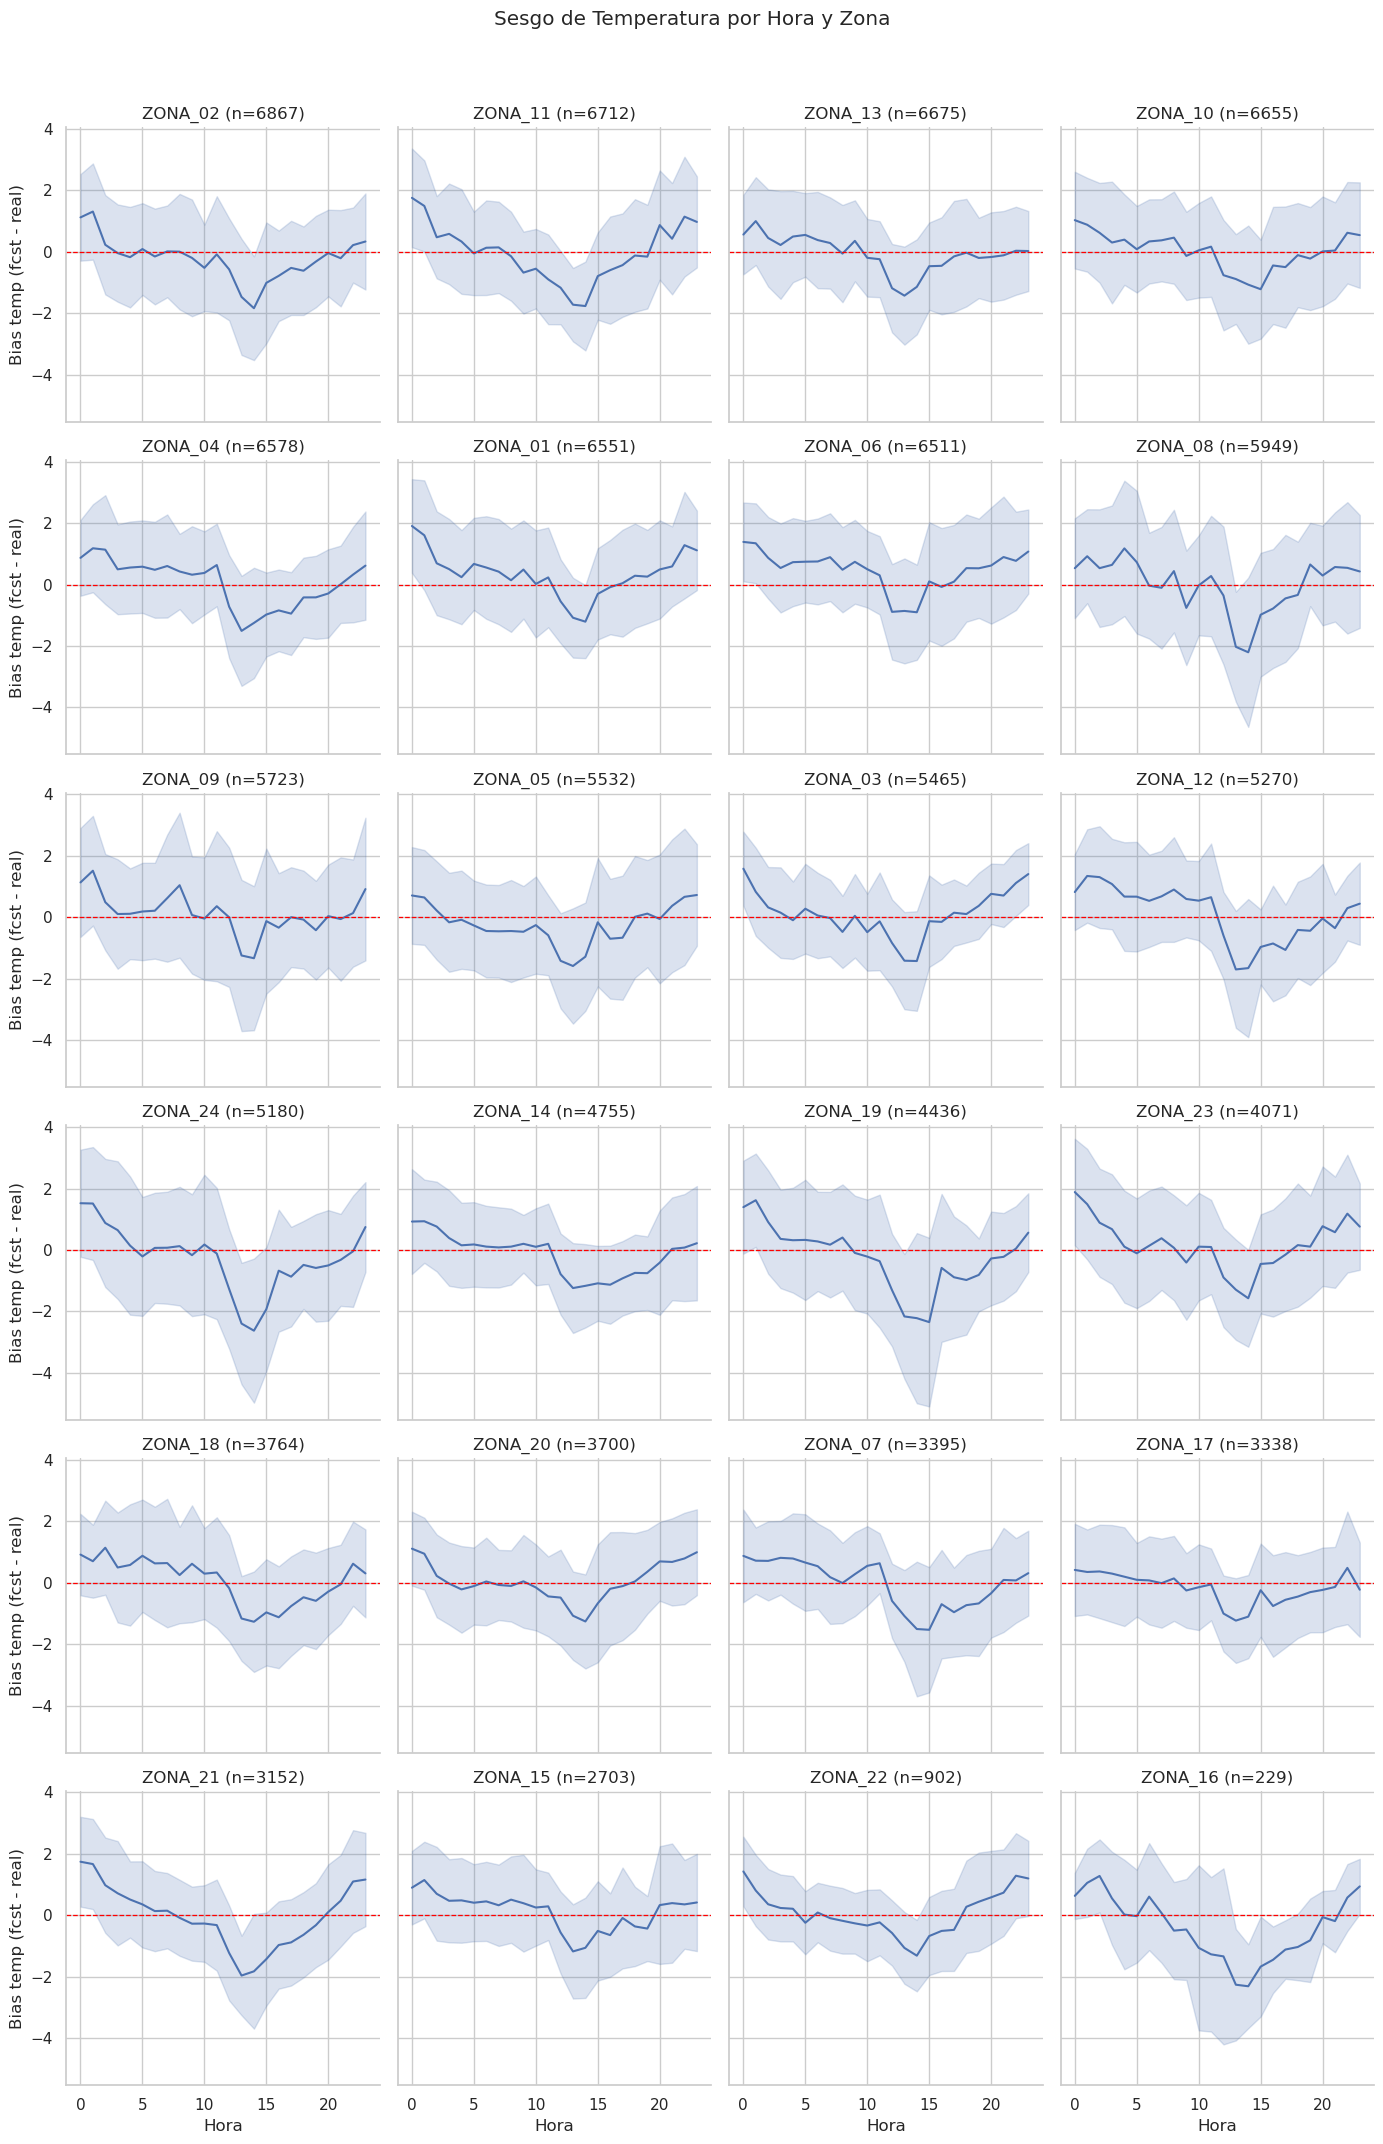

In [15]:
# Análisis de sesgo diurno por zona (subplots por zona)
subset = df.dropna(subset=["err_temp", "hour", "zona_id"]).copy()

# Seleccionar zonas con suficiente muestra; si no hay, elegir top N
counts = subset["zona_id"].value_counts()
zones = counts[counts >= 200].index.tolist()
if not zones:
    zones = counts.index[:8].tolist()

plot_df = subset[subset["zona_id"].isin(zones)]

ncols = min(4, len(zones))
g = sns.FacetGrid(plot_df, col="zona_id", col_wrap=ncols, height=3.5, sharey=True)
g.map_dataframe(sns.lineplot, x="hour", y="err_temp", errorbar="sd")
g.set_axis_labels("Hora", "Bias temp (fcst - real)")
g.set_titles(col_template="{col_name}")

for ax, zone in zip(g.axes.flatten(), zones):
    ax.set_title(f"{zone} (n={counts.loc[zone]})")

for ax in g.axes.flatten():
    ax.axhline(0, color="red", linestyle="--", linewidth=0.9)

plt.suptitle("Sesgo de Temperatura por Hora y Zona", y=1.02)
plt.tight_layout()

## 4. Persistencia Temporal (Lags)

**Observaciones:**

- El error actual está altamente correlacionado con el error de la hora anterior (~0.66).
- **Estrategia:** Incluir lags de 1h y 3h como características del modelo.


Correlación Lag 1h para err_temp: 0.663
Correlación Lag 1h para err_hum: 0.663
Correlación Lag 1h para err_wind: 0.455
Correlación Lag 1h para err_dew: 0.662


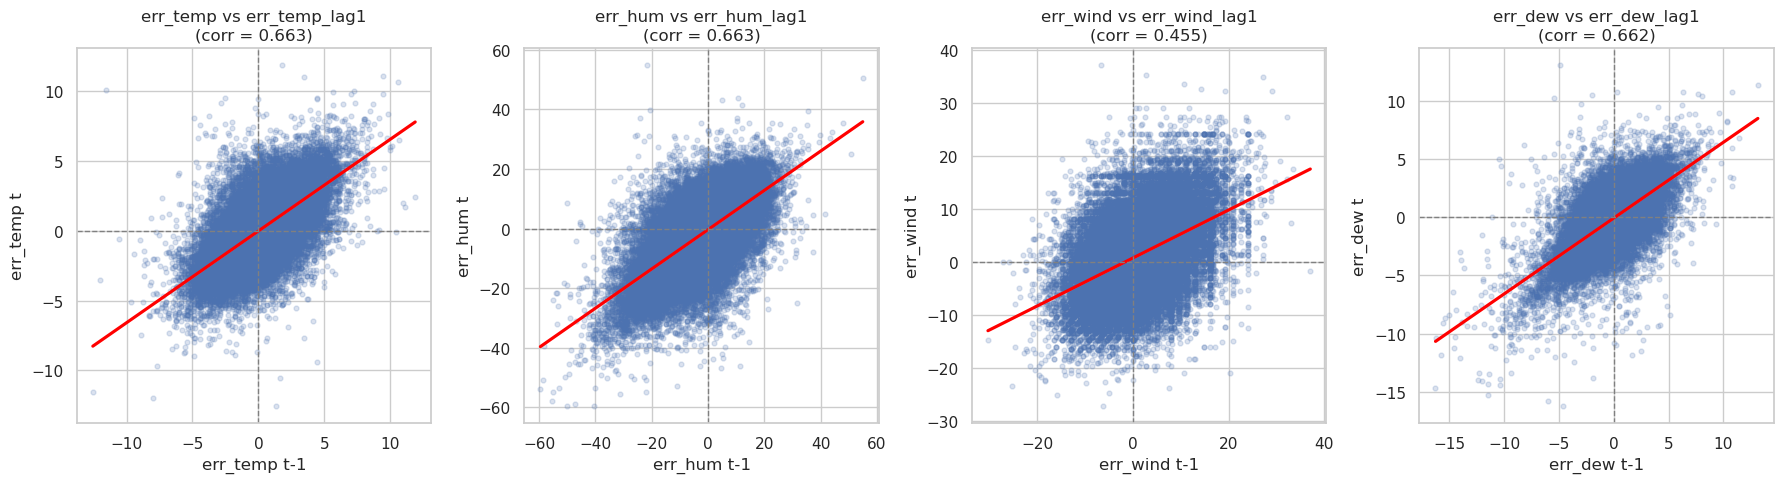

In [16]:
# Persistencia temporal
lag_vars = ["err_temp", "err_hum", "err_wind", "err_dew"]

df = df.sort_values(["station_id", "obs_timestamp"]).copy()

lag_corrs = {}

for var in lag_vars:
    lag_col = f"{var}_lag1"
    df[lag_col] = df.groupby("station_id")[var].shift(1)
    lag_corrs[var] = df[[var, lag_col]].corr().iloc[0, 1]
    print(f"Correlación Lag 1h para {var}: {lag_corrs[var]:.3f}")

fig, axes = plt.subplots(1, len(lag_vars), figsize=(18, 5))

for ax, var in zip(axes, lag_vars):
    lag_col = f"{var}_lag1"
    plot_df = df[[var, lag_col]].dropna()

    sns.regplot(
        data=plot_df,
        x=lag_col,
        y=var,
        scatter_kws={"alpha": 0.2, "s": 12},
        line_kws={"color": "red"},
        ax=ax,
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{var} vs {lag_col}\n(corr = {lag_corrs[var]:.3f})")
    ax.set_xlabel(f"{var} t-1")
    ax.set_ylabel(f"{var} t")

plt.tight_layout()
plt.show()

Correlación Lag 3h para err_temp: 0.245
Correlación Lag 3h para err_hum: 0.298
Correlación Lag 3h para err_wind: 0.185
Correlación Lag 3h para err_dew: 0.302


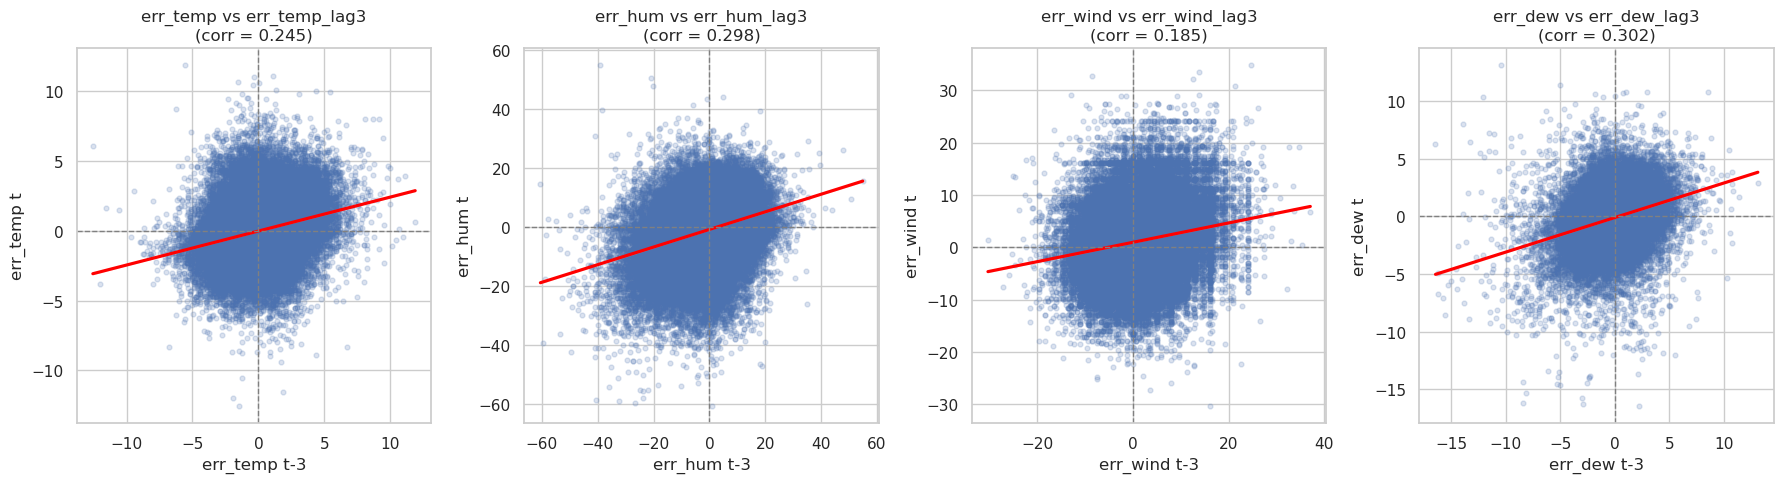

In [17]:
# Persistencia temporal (lag 3h)
lag_vars = ["err_temp", "err_hum", "err_wind", "err_dew"]

df = df.sort_values(["station_id", "obs_timestamp"]).copy()

lag_corrs = {}

for var in lag_vars:
    lag_col = f"{var}_lag3"
    df[lag_col] = df.groupby("station_id")[var].shift(3)
    lag_corrs[var] = df[[var, lag_col]].corr().iloc[0, 1]
    print(f"Correlación Lag 3h para {var}: {lag_corrs[var]:.3f}")

fig, axes = plt.subplots(1, len(lag_vars), figsize=(18, 5))

for ax, var in zip(axes, lag_vars):
    lag_col = f"{var}_lag3"
    plot_df = df[[var, lag_col]].dropna()

    sns.regplot(
        data=plot_df,
        x=lag_col,
        y=var,
        scatter_kws={"alpha": 0.2, "s": 12},
        line_kws={"color": "red"},
        ax=ax,
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{var} vs {lag_col}\n(corr = {lag_corrs[var]:.3f})")
    ax.set_xlabel(f"{var} t-3")
    ax.set_ylabel(f"{var} t")

plt.tight_layout()
plt.show()

## 5. Distribución de Residuos

**Observaciones:**

- Tras filtrar el glitch de la NWS (60°C), la temperatura muestra una distribución mucho más centrada y simétrica.



Estadísticas para err_temp:
Mean Bias: -0.0042
MAE: 1.3089
Kurtosis: 1.4052

Estadísticas para err_hum:
Mean Bias: -1.1736
MAE: 6.6734
Kurtosis: 1.6147

Estadísticas para err_wind:
Mean Bias: 1.2642
MAE: 4.5837
Kurtosis: 0.7574

Estadísticas para err_dew:
Mean Bias: -0.1416
MAE: 1.2122
Kurtosis: 4.6212


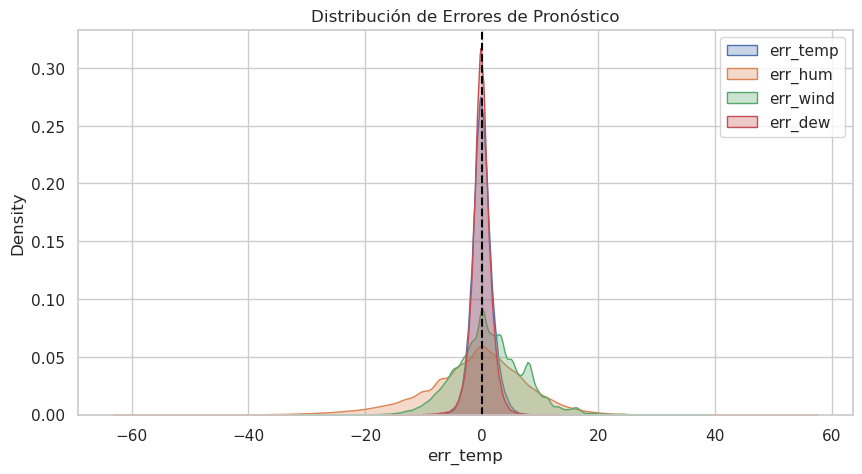

In [18]:
err_vars = ["err_temp", "err_hum", "err_wind", "err_dew"]
for var in err_vars:
    print(f"\nEstadísticas para {var}:")
    print(f"Mean Bias: {df[var].mean():.4f}")
    print(f"MAE: {df[var].abs().mean():.4f}")
    print(f"Kurtosis: {kurtosis(df[var].dropna()):.4f}")

plt.figure(figsize=(10, 5))
for var in err_vars:
    sns.kdeplot(df[var], label=var, fill=True, alpha=0.3)
plt.axvline(0, color="black", linestyle="--")
plt.legend()
plt.title("Distribución de Errores de Pronóstico")
plt.show()


Estadísticas por zona para err_temp:


,mean_bias,mae,std,skew,kurtosis,n
zona_id,,,,,,
ZONA_17,-0.176516,1.646072,2.139978,0.088382,0.864889,2676
ZONA_15,-0.194106,1.588005,2.033269,-0.174873,0.509252,2251
ZONA_12,0.137422,1.542389,1.955233,0.181847,0.231140,3973
ZONA_22,-0.063490,1.506047,2.017653,-0.131355,1.400487,836
ZONA_21,0.102626,1.492292,2.012388,0.399071,1.767227,2628
ZONA_08,-0.235291,1.458228,1.848442,0.211249,0.419443,5443
ZONA_16,-0.443250,1.426523,1.865336,-0.562019,0.810753,186
ZONA_19,0.313954,1.367346,1.725840,0.497977,0.393109,4217
ZONA_14,0.112918,1.362444,1.820618,-0.001332,1.660888,4084



Estadísticas por zona para err_hum:


,mean_bias,mae,std,skew,kurtosis,n
zona_id,,,,,,
ZONA_12,-2.011346,7.724820,10.093569,-0.530502,0.617768,3973
ZONA_06,-2.155256,7.502481,10.079343,-0.585027,1.559270,4642
ZONA_14,-1.473919,7.419825,9.976818,-0.364309,1.381808,4084
ZONA_08,-1.588022,7.416810,9.313844,-0.257283,0.391837,5443
ZONA_20,-2.666174,7.381471,10.496126,-1.216449,2.488444,3330
ZONA_19,-3.361209,7.283458,9.382584,-0.690365,0.502495,4217
ZONA_24,0.195334,6.865205,8.768450,-0.301135,0.425405,4686
ZONA_23,-0.439977,6.828877,8.822666,-0.437971,0.786362,3702
ZONA_05,-1.620180,6.770071,8.903101,-0.649305,1.021133,4728



Estadísticas por zona para err_wind:


,mean_bias,mae,std,skew,kurtosis,n
zona_id,,,,,,
ZONA_22,1.930060,5.899689,7.415923,0.136705,0.522285,836
ZONA_17,1.928875,5.393434,6.745955,0.230339,0.571712,2676
ZONA_21,1.618605,5.339033,6.621778,0.215012,0.176271,2628
ZONA_20,2.042825,5.321502,6.550192,0.146946,0.443770,3330
ZONA_16,2.158066,5.176758,5.899944,-0.179850,-0.415258,186
ZONA_14,0.796275,5.158655,6.632447,0.163842,0.535240,4084
ZONA_18,1.034193,5.002506,6.416680,0.070193,0.671510,3494
ZONA_15,0.638347,4.830780,6.172185,0.083663,0.434923,2251
ZONA_03,1.763314,4.752735,5.999254,0.394193,0.820720,4685



Estadísticas por zona para err_dew:


,mean_bias,mae,std,skew,kurtosis,n
zona_id,,,,,,
ZONA_20,-0.681732,2.095679,2.887345,-0.984239,2.591170,3330
ZONA_17,-0.648808,1.828587,2.517419,-0.746995,3.260335,2676
ZONA_21,-0.221334,1.775402,2.548844,-0.849478,3.742424,2628
ZONA_16,0.608722,1.645759,1.892831,0.016232,-0.176729,186
ZONA_06,-0.552183,1.351206,1.879579,-0.618070,6.649908,4642
ZONA_15,-0.139726,1.339123,1.878158,-0.323128,3.744627,2251
ZONA_22,-0.041627,1.320893,1.733572,-0.044434,1.012900,836
ZONA_14,-0.070846,1.292698,1.734942,0.080497,1.642631,4084
ZONA_08,-0.419754,1.208188,1.473988,-0.001295,0.325056,5443


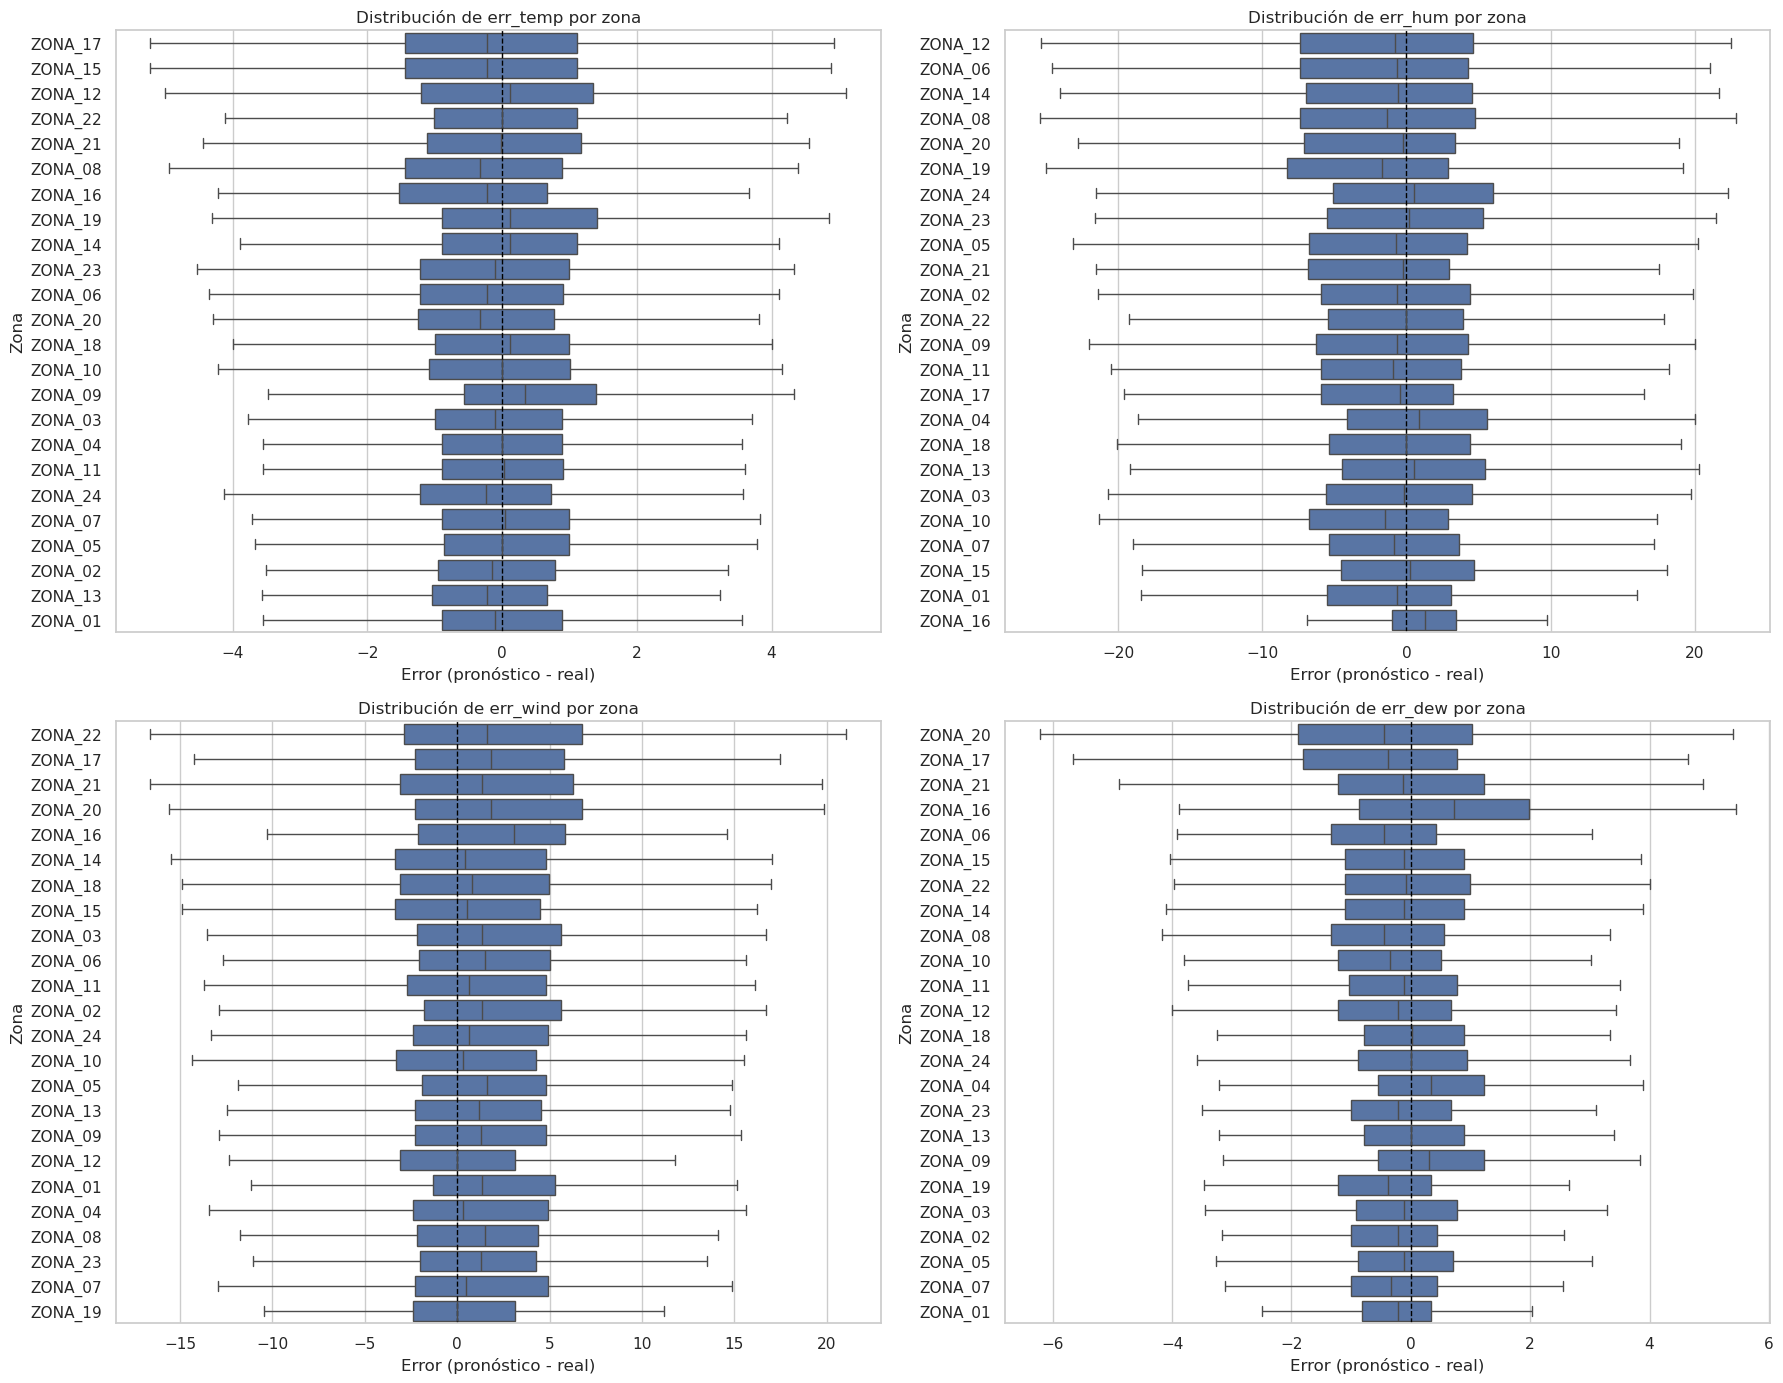

In [19]:
# Distribución de residuos por zona

zone_df = df.dropna(subset=["zona_id"] + err_vars).copy()

for var in err_vars:
    print(f"\nEstadísticas por zona para {var}:")
    zone_stats = (
        zone_df.groupby("zona_id")[var]
        .agg(
            mean_bias="mean",
            mae=lambda x: np.mean(np.abs(x)),
            std="std",
            skew=lambda x: skew(x.dropna()),
            kurtosis=lambda x: kurtosis(x.dropna()),
            n="count",
        )
        .sort_values("mae", ascending=False)
    )
    display(zone_stats.head(10))

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, var in zip(axes, err_vars):
    order = (
        zone_df.groupby("zona_id")[var]
        .apply(lambda x: np.mean(np.abs(x)))
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=zone_df,
        y="zona_id",
        x=var,
        order=order,
        ax=ax,
        showfliers=False,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Distribución de {var} por zona")
    ax.set_xlabel("Error (pronóstico - real)")
    ax.set_ylabel("Zona")

plt.tight_layout()
plt.show()

## 7. Variabilidad Espacial

**Observaciones:**

- El error es consistente en la zona central para temperatura, humedad y punto de rocio. Pero el MAE para la velocidad del viento considerablemente mas alto en una subseccion del area de estudio.


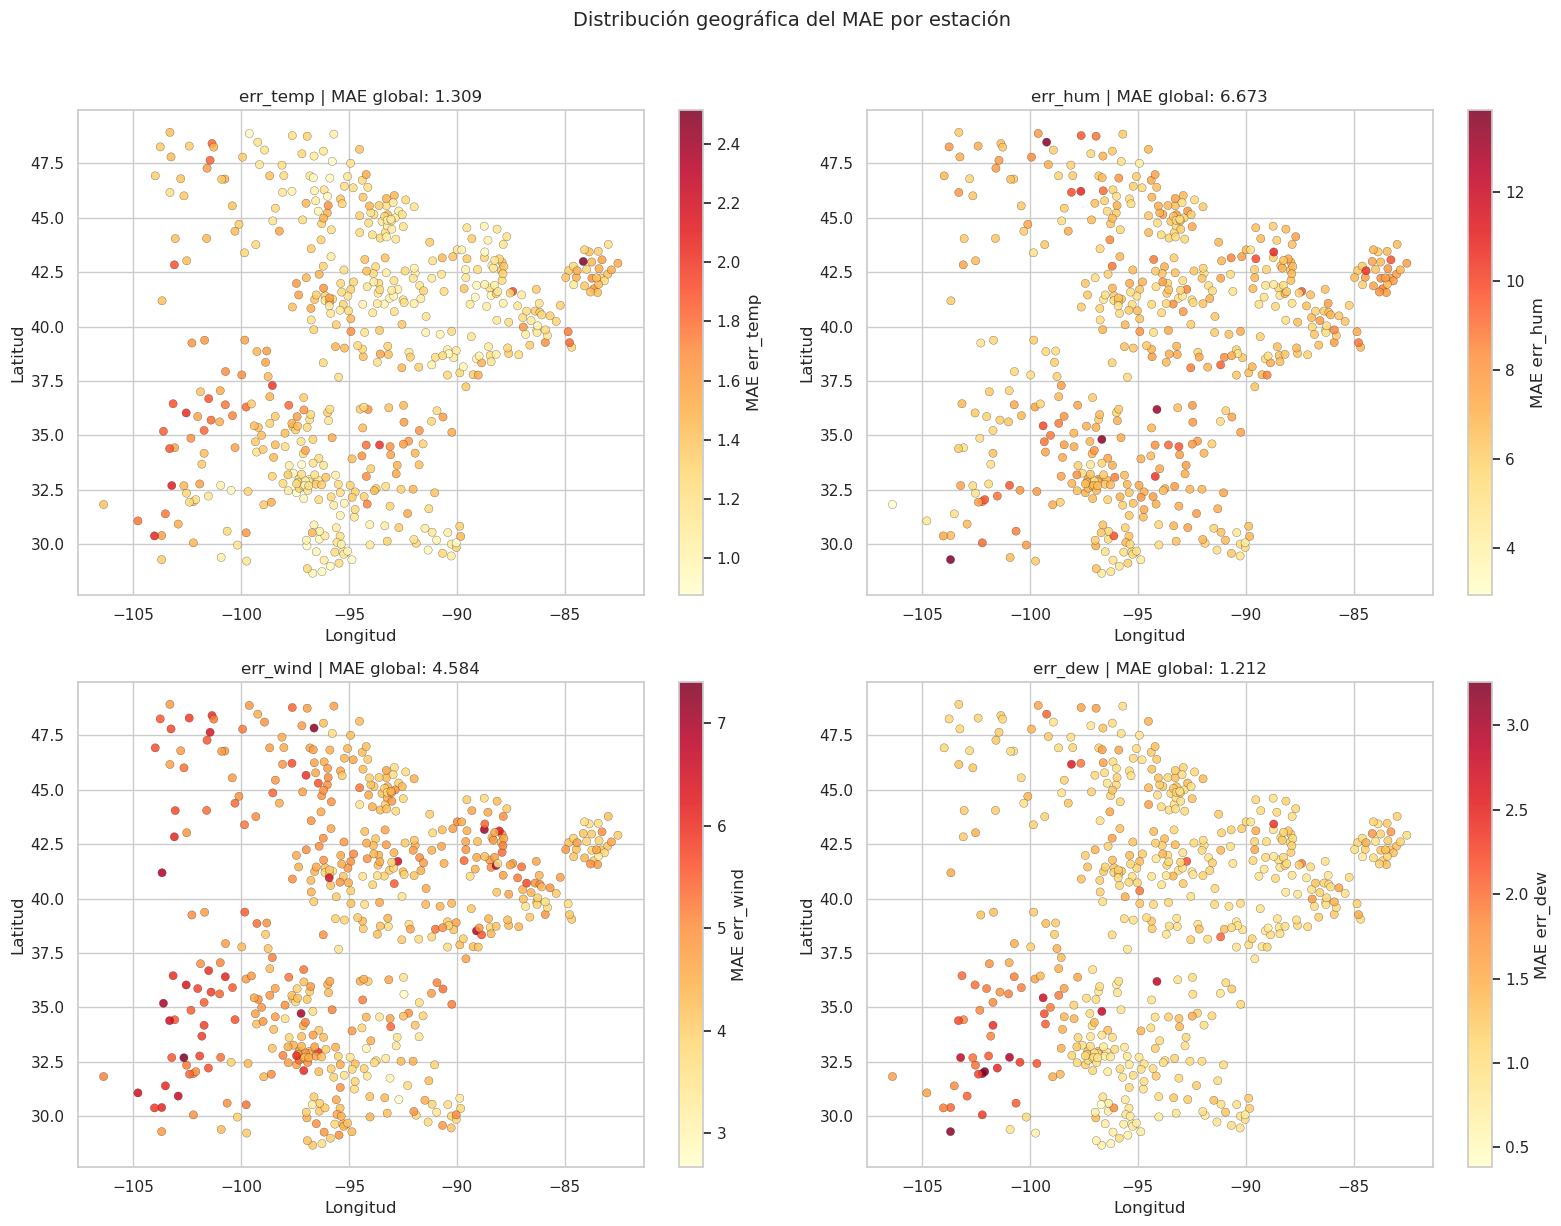


Top 10 estaciones con mayor MAE para err_temp:


,station_id,mae,n_obs
424,KRNP,2.513564,222
240,KHOB,2.097820,209
344,KMRF,2.056769,229
130,KDHT,2.049874,221
353,KMWT,2.018819,222
383,KP28,1.995742,227
230,KGYY,1.927371,205
87,KCAO,1.901932,230
94,KCDR,1.899803,226
224,KGUY,1.888889,233



Top 10 estaciones con mayor MAE para err_hum:


,station_id,mae,n_obs
459,KT89,13.820720,13
23,K9D7,13.591297,137
32,KADH,13.576757,200
52,KASG,13.177367,145
220,KGWR,10.854812,217
484,KUNU,10.821764,44
462,KTEW,10.466514,95
53,KATA,10.436115,133
159,KELK,10.011714,213
18,K60R,9.859978,166



Top 10 estaciones con mayor MAE para err_wind:


,station_id,mae,n_obs
217,KGNC,7.395000,229
102,KCKN,7.232484,219
405,KPVJ,7.025449,220
432,KRYV,7.014365,20
278,KJOT,6.946700,226
473,KTCC,6.943662,193
254,KIBM,6.881643,219
164,KENL,6.845244,210
195,KFST,6.618194,224
118,KCVS,6.536719,204



Top 10 estaciones con mayor MAE para err_dew:


,station_id,mae,n_obs
315,KMDD,3.255163,170
459,KT89,3.157895,19
310,KMAF,3.044239,216
442,KSNK,2.940663,191
52,KASG,2.846743,145
32,KADH,2.836374,201
234,KHOB,2.792793,185
159,KELK,2.695216,216
11,K2D5,2.543272,199
70,KBPG,2.439744,208


In [20]:
# MAE geográfico por estación para las 4 variables de error

geo_mae = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, var in zip(axes, err_vars):
    mae_geo = (
        df.dropna(subset=[var, "lat_estacion", "lon_estacion"])
        .groupby("station_id", as_index=False)
        .agg(
            lat_estacion=("lat_estacion", "first"),
            lon_estacion=("lon_estacion", "first"),
            mae=(var, lambda x: np.mean(np.abs(x))),
            n_obs=(var, "count"),
        )
    )

    geo_mae[var] = mae_geo
    global_mae = df[var].abs().mean()

    sc = ax.scatter(
        mae_geo["lon_estacion"],
        mae_geo["lat_estacion"],
        c=mae_geo["mae"],
        cmap="YlOrRd",
        s=35,
        alpha=0.85,
        edgecolor="k",
        linewidth=0.2,
    )

    ax.set_title(f"{var} | MAE global: {global_mae:.3f}")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.colorbar(sc, ax=ax, label=f"MAE {var}")

plt.suptitle("Distribución geográfica del MAE por estación", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

for var in err_vars:
    print(f"\nTop 10 estaciones con mayor MAE para {var}:")
    display(
        geo_mae[var][["station_id", "mae", "n_obs"]]
        .sort_values("mae", ascending=False)
        .head(10)
    )

## 8. Análisis de Sesgo Condicional

**Observaciones:**

- Mayor dispersión en extremos térmicos (<5C o >35C).


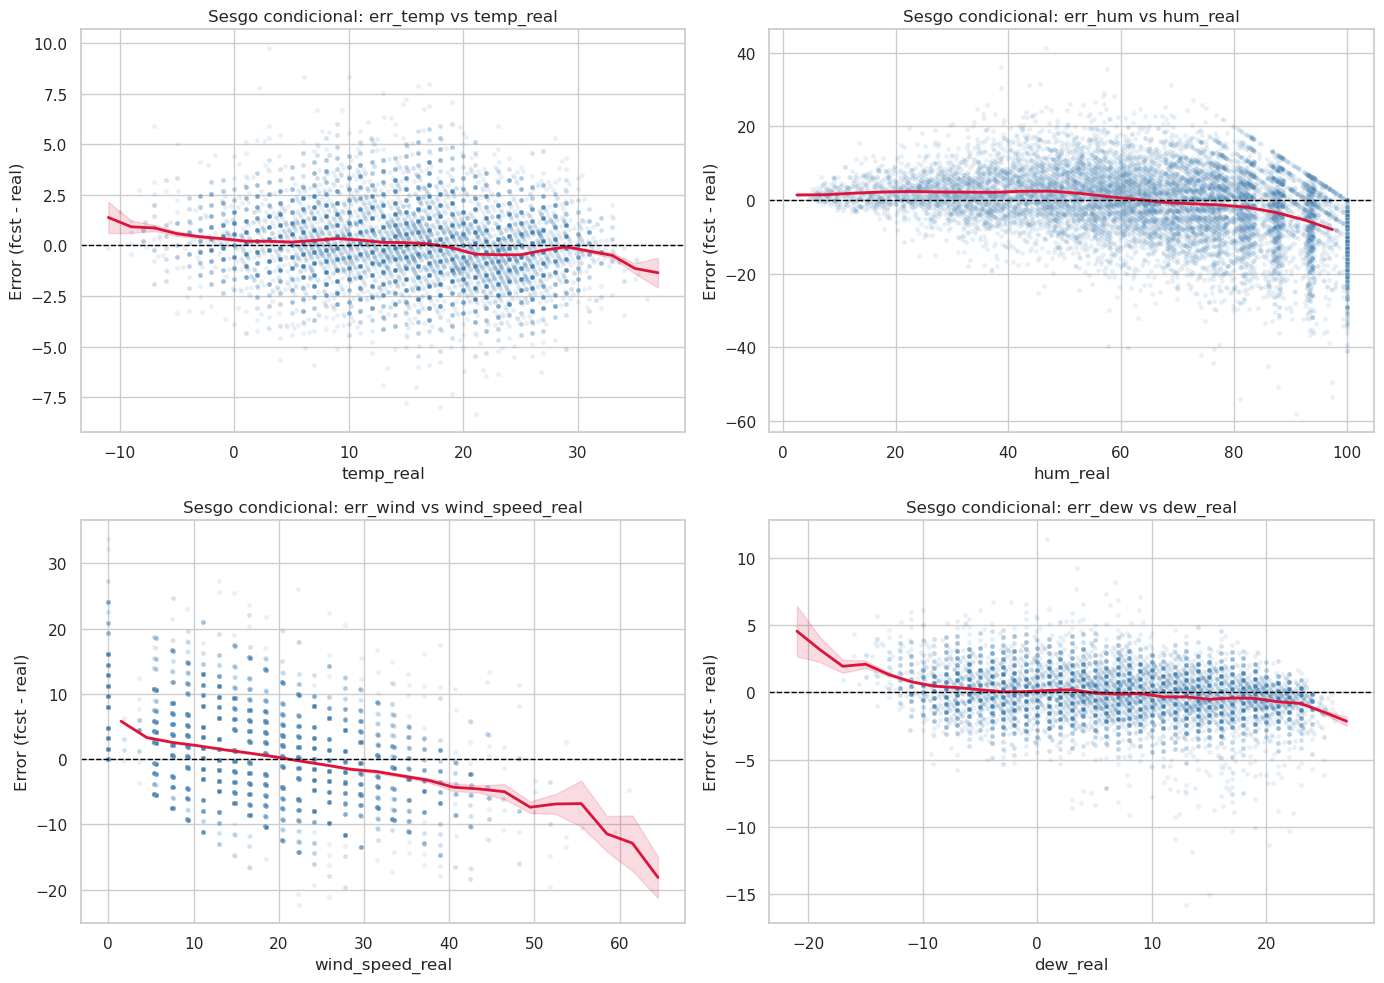

In [23]:
# Análisis de sesgo condicional
obs_map = {
    "err_temp": "temp_real",
    "err_hum": "hum_real",
    "err_wind": "wind_speed_real",
    "err_dew": "dew_real",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, var in zip(axes, err_vars):
    obs_col = obs_map[var]
    cond_df_var = df[[obs_col, var]].dropna().copy()
    if cond_df_var.empty:
        ax.set_title(f"{var} (sin datos)")
        continue

    # escoger ancho de bin por variable
    if var == "err_hum":
        width = 5.0
    elif var == "err_wind":
        width = 3
    else:  # temp, dew
        width = 2.0

    vmin = cond_df_var[obs_col].min()
    vmax = cond_df_var[obs_col].max()
    if vmin == vmax:
        bins = np.array([vmin - 0.5 * width, vmax + 0.5 * width])
    else:
        bins = np.arange(
            np.floor(vmin / width) * width, np.ceil(vmax / width) * width + width, width
        )

    cond_df_var["bin"] = pd.cut(cond_df_var[obs_col], bins=bins, include_lowest=True)
    bias_by_bin_var = (
        cond_df_var.groupby("bin", observed=False)[var]
        .agg(mean_bias="mean", std="std", n="count")
        .reset_index()
    )
    bias_by_bin_var["center"] = bias_by_bin_var["bin"].apply(lambda x: x.mid)
    bias_by_bin_var["ci95"] = 1.96 * (
        bias_by_bin_var["std"] / np.sqrt(bias_by_bin_var["n"])
    )
    bias_by_bin_var["ci95"] = bias_by_bin_var["ci95"].fillna(0)

    # nube de puntos (muestreo para no sobrecargar)
    sample = cond_df_var.sample(min(12000, len(cond_df_var)), random_state=42)
    sns.scatterplot(
        data=sample, x=obs_col, y=var, alpha=0.12, s=12, color="steelblue", ax=ax
    )

    # sesgo medio por bin + IC95
    ax.plot(
        bias_by_bin_var["center"], bias_by_bin_var["mean_bias"], color="crimson", lw=2
    )
    ax.fill_between(
        bias_by_bin_var["center"],
        bias_by_bin_var["mean_bias"] - bias_by_bin_var["ci95"],
        bias_by_bin_var["mean_bias"] + bias_by_bin_var["ci95"],
        color="crimson",
        alpha=0.15,
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Sesgo condicional: {var} vs {obs_col}")
    ax.set_xlabel(obs_col)
    ax.set_ylabel("Error (fcst - real)")

plt.tight_layout()
plt.show()

## 9. Conclusiones y Estrategia de Modelado

### Hallazgos Críticos

1. **Glitch de Proveedor:** Se confirmó que valores > 50°C eran errores técnicos de la NWS (Milwaukee), los cuales ya fueron filtrados en el pipeline de unificación.
2. **Correlacion apreciable entre residuos con lag de 1h y 3h:** Target para feature engineering y correccion de pronostico.
3. **MAE para wind_speed variable en el espacio:** Posible sesgo geográfico que podría ser corregido con variables de ubicación o modelos de ML específicos por zona.
4. **Sesgo Diurno:** Necesidad de incorporar la hora del día como variable predictora, idealmente transformada en componentes sinusoidales para capturar la naturaleza cíclica.

### Próximos Pasos (Feature Engineering)

- Generar variables cíclicas para `hour`.
- Crear ventanas de `lags` (t-1, t-3).
- Implementar modelos de ensamble (XGBoost/LightGBM) para predecir los residuos identificados.
